<a href="https://colab.research.google.com/github/LiaIssakov/Portfolio_2025/blob/main/clustering_intro_fall26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist, fashion_mnist

> Improvements by Nikhil_Giridharan in Fall 2023!

# New tool: k-means clustering

> Recall that we computed the 'mean digit' as the mean of all images showing a particular digit (using the mnist dataset). For example the 'mean zero' was the mean of all images showing zeros. Each 'mean digit' was a good **representative** for its class. BUUUUT: We cheated and used the labels!

## Can we do something similar WITHOUT ACCESS to the labels ?

In other words, we are now in the **unsupervised learning setting**.

> Enter **k-means clustering** - a popular unsupervised algorithm. Specifically, it's for centroid-based clustering, which focuses on finding good representatives.

> For now we treat of it as a black-box and just use it -- soon we'll open it up and understand it!




# Simple dataset in 2D
##Lets generate 3 random blobs of points##


In [2]:
def generate_blobs(k, n, width, d=2):
  '''Just generates k blobs, each of size n.
  '''
  C = np.random.random((1, k, d))
  X = C + np.random.randn(n, k, d)*width
  return X.reshape((k*n, d))

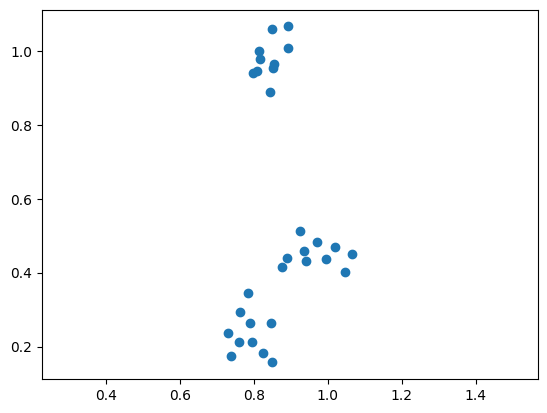

In [4]:
np.random.seed(13)
X = generate_blobs(3, 10, 0.05)
plt.scatter(X.T[0], X.T[1])
plt.axis('equal');

# Task 1

## What 3 points on the plane would represent these three blobs well?

> Let's Fill in C1, C2 and C3 with some guesses as to what the middle is, you can be as precise as you desire

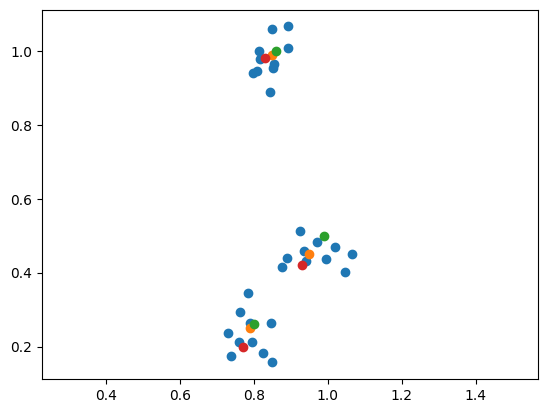

In [21]:
# fill in your best guess for representatives of the 3 clusters below
C1 = np.array([(.85, 0.99), (0.79, .25), (.95, 0.45)]) # orange point

# We'll use this in a moment
C2 = np.array([(0.86, 1.0), (0.8, 0.26), (0.99, 0.50)]) # green point
C3 = np.array([(0.83, 0.98), (0.77, 0.20), (.93, 0.42)]) # red point

plt.scatter(X.T[0], X.T[1])

for C in [C1, C2, C3]:
  plt.scatter(C.T[0], C.T[1])

plt.axis('equal');

## In a moment we will learn to do this automatically (again: without access to labels!)

## Using kMeans (specifically)

- We need to import it (see code below).

- We create an instance of the kmeans algorithm for a particular number of clusters (3 in our case). (Just because we happen to know there are 3 blobs). We can think of it as a model -- but it hasn't seen any data yet.

- Then we *fit* our model with dataset X. **The data must be a bunch of flat vectors!** So not a bunch of two-dimensional np arrays! You may have to reshape your data!

- Then we can ask it for several things:
  - **cluster_centers_** : array of k cluster centers (aka centroids)
  - labels_: array of labels for each point in X. The label is just the index of the nearest cluster center.  
- optional:
  - predict(P)  : assigns each vector in P to the nearest cluster center.
  - transform(P) : represents each vector in P as a vector of distances to the centers (we won't use this now, don't worry about this)

> In the future we'll often use the fit_transform function, but here it's not useful (just because we're not using transform).

> tip: you can always ask for help, e.g. help(km.predict) will explain what the predict function does
  
  


In [12]:
from sklearn.cluster import KMeans

In [28]:
km = KMeans(n_clusters=3) # initialize the model so it makes 3 clusters

In [29]:
km.fit(X); # fit with dataset X

In [30]:
cs = km.cluster_centers_ # get the array of k cluster centers # underscore at the end is necessary

In [31]:
cs.shape

(3, 2)

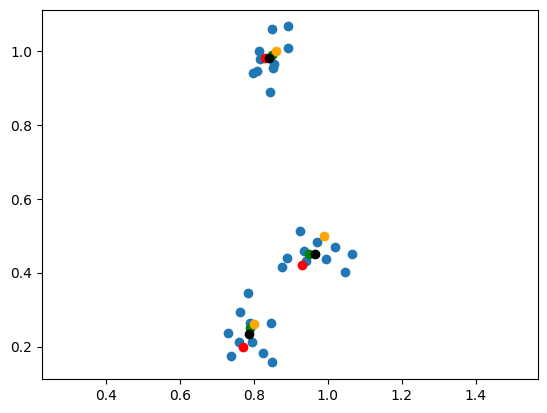

In [32]:
# compare the results with your best bet above
plt.scatter(X.T[0], X.T[1])

plt.scatter(C1.T[0], C1.T[1], c='green')
plt.scatter(C2.T[0], C2.T[1], c='orange')
plt.scatter(C3.T[0], C3.T[1], c='red')
plt.scatter(cs.T[0], cs.T[1], c='black')

plt.axis('equal');

#Extra

##What if we chose a different number of clusters?


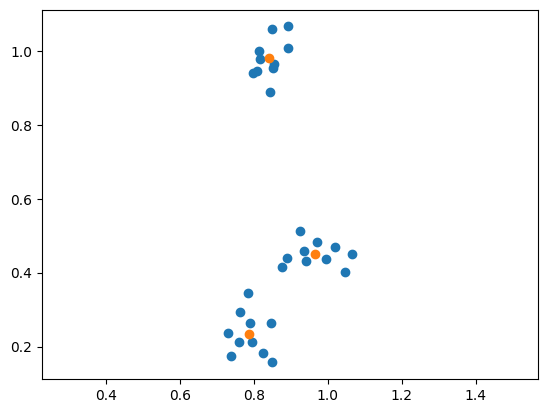

In [38]:
km2 = KMeans(n_clusters=3, n_init='auto')
km2.fit(X)
cs2 = km2.cluster_centers_
plt.scatter(X.T[0], X.T[1])
plt.scatter(cs2.T[0], cs2.T[1])

plt.axis('equal');

>Lets try running it with 4 clusters, see if you get the same results as your neighbor...

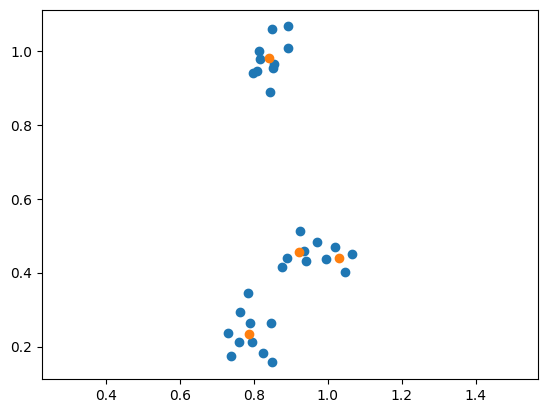

In [42]:
km4 = KMeans(n_clusters=4, n_init='auto')
km4.fit(X)
cs4 = km4.cluster_centers_

plt.scatter(X.T[0], X.T[1])
plt.scatter(cs4.T[0], cs4.T[1])

plt.axis('equal');

# Using sklearn models (in general)

> We use Kmeans clustering algorithm from the sklearn python library

> We will use many algorithms from this library, which have a similar *interface*.

It may seem strange at first, but sklearn represents each algorithm as a class (just like list, np.array were classes).

This is what we do:
- So we will first create an object (variable) for a specific algorithm.
- We will think of it as our *model*.
- We then *fit* it with data. And then we can query it using methods/function which are called *predict* and *transform*. These names shared by many different algorithms.
- We can also access various properties which whose names are specific to a given algorithm.




# Important task 1: clustering images

## Now apply k-means to the mnist dataset

Some questions to consider and discuss:
- each cluster center (aka centroid) is a vector -- of what dimension? 2? 3? something else?
- Can we somehow plot each centroid, or otherwise visualize it

In [71]:
from keras.datasets import fashion_mnist

#we dont care about the labels or test data
(x_train, _), (_) = mnist.load_data() # you an use fashion_mnist, too
x_train = x_train/255. # normalize as usual

In [72]:
# initialize kmeans
# specify n_init to remove a warning -- and to make sure it'll run
# the same way in, say, a year
km = KMeans(n_clusters=20, n_init='auto')

In [73]:
# fit kmeans with our data (remember to reshape!)
km.fit(x_train.reshape(60000, 28*28));
# you can specify one dimension as -1, numpy will figure out the correct number

In [74]:
# assign the cluster centers to a variable centers_as_images
centers_as_images = km.cluster_centers_.reshape(-1, 28, 28)

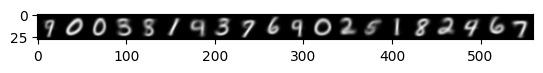

In [75]:
# Maybe it's best to show them all in one go
plt.imshow(np.concatenate(centers_as_images, axis=1), cmap='gray')

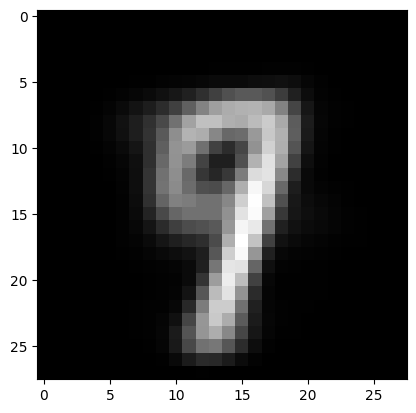

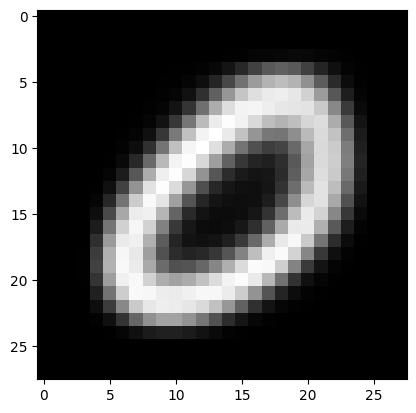

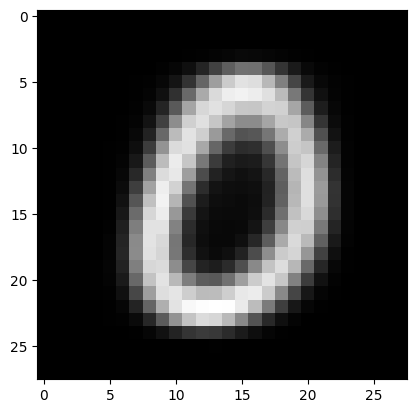

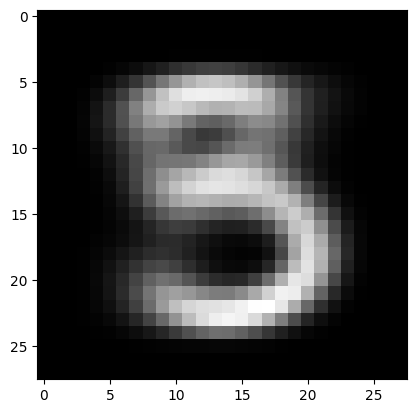

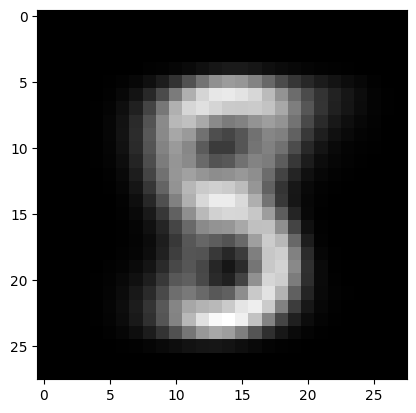

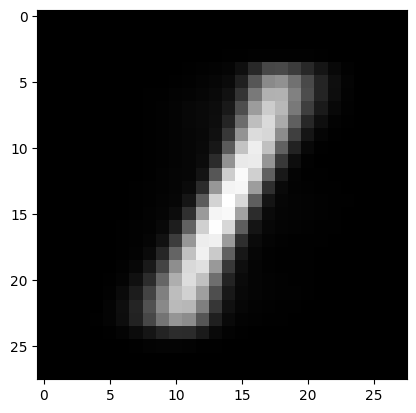

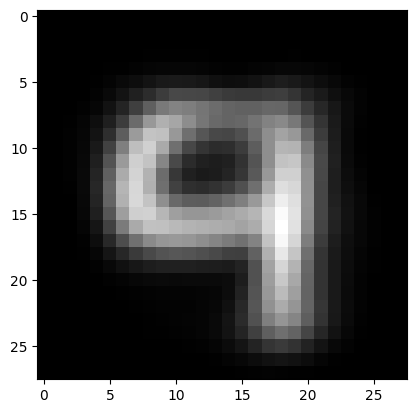

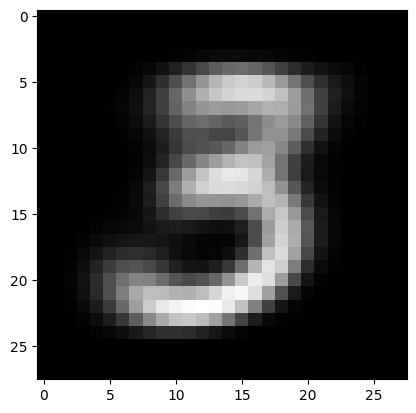

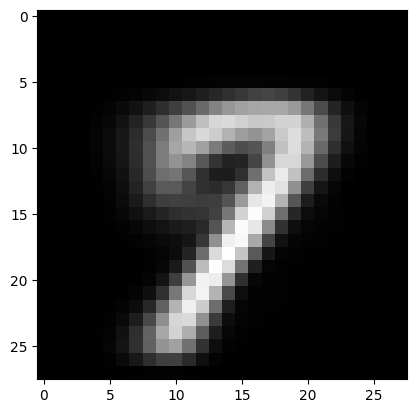

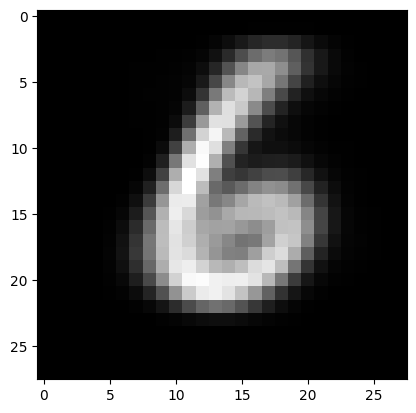

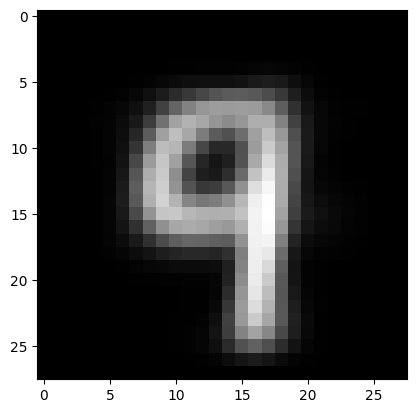

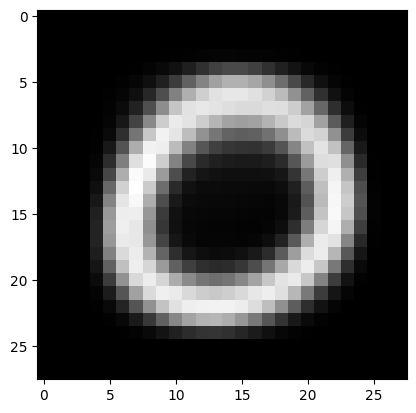

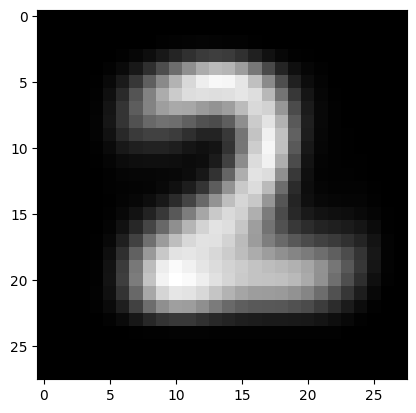

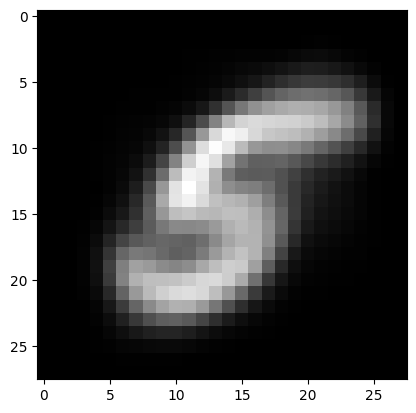

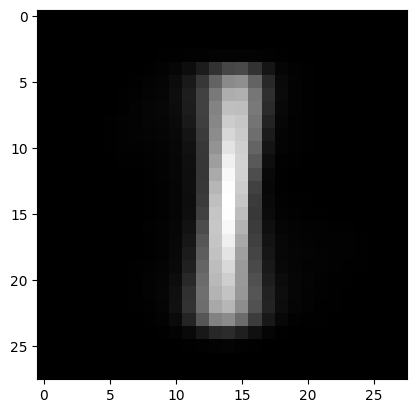

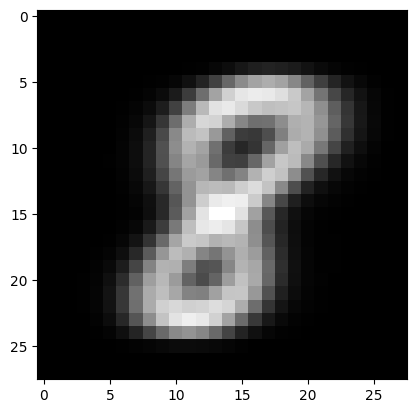

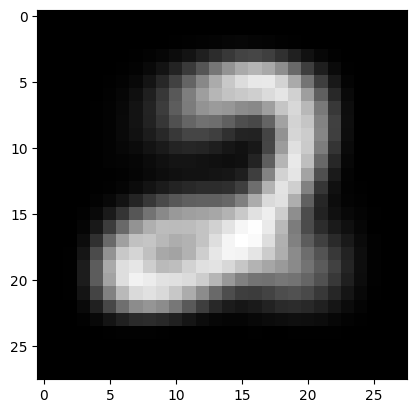

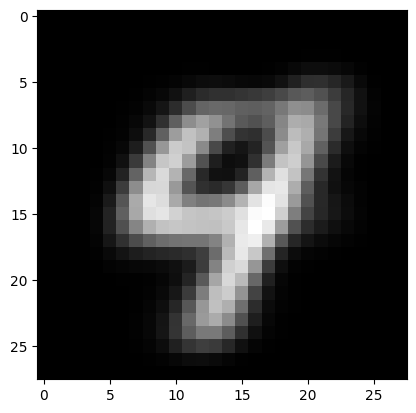

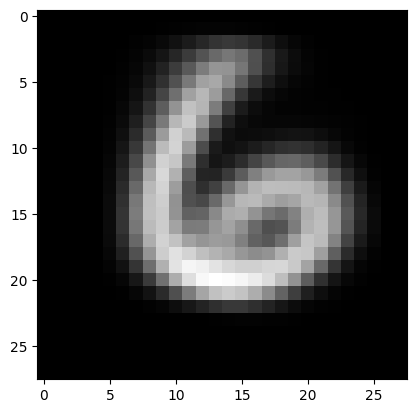

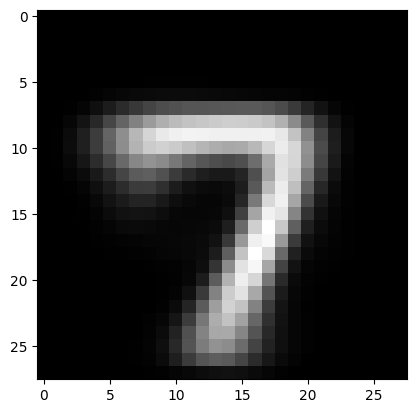

In [76]:
# Or separately as larger images, if you want
for im in centers_as_images:
  plt.imshow(im, cmap='gray')
  plt.show()

In [ ]:
# repeat for a different k if necessery

>Ideally, our centers would be each digit since we have 10 centers, but as we can see that is not necessarily the case...any thoughts?

# Small Task 2

Repeat the above but for a selected digis, e.g. 7. Try to see how many distinct ways of writing this number there may be. Play with different number of clusters.

> Please load the y_train just to get the sevens.

# Task 3 (optional)

> Let's go back to the 2D case

To check the quality of clustering, we can compute the sum of Euclidean distances from each vector in the dataset to the nearest center. So compute this sum for your choice and for the output of kmeans.

> You may have noticed a detail is missing -- we'll get to that next time.

Did kmeans give better centers than the ones you chose by hand/eye?

> Could k-means be actually *optimal*? In the sense that it gives clusters that minimize the above sum?

# Task 4 (optional)

> You can do this either in the 2D case or for images. 2D may be slightly easier.

Verify that each center given by km.cluster_centers_ is actually the mean of the vectors for which this center is the closest among all centers.

> And now read the previous sentence 10 times :).

> If only we could have good words for complicated things like that...